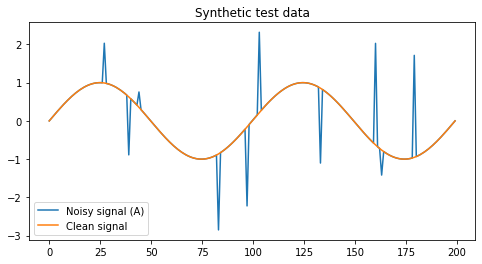

In [1]:
import torch
import matplotlib.pyplot as plt
from selfmixed_model import *

# Set random seed for reproducibility
torch.manual_seed(0)

# Create synthetic "clean" signal
n = 200
A_clean = torch.sin(torch.linspace(0, 4 * torch.pi, n))

# Add sparse noise (few large spikes)
S_true = torch.zeros(n)
idx = torch.randint(0, n, (10,))
S_true[idx] = torch.randn(10) * 2.5

# Observed noisy signal
A_noisy = A_clean + S_true

plt.figure(figsize=(8,4))
plt.plot(A_noisy.numpy(), label='Noisy signal (A)')
plt.plot(A_clean.numpy(), label='Clean signal')
plt.legend()
plt.title("Synthetic test data")
plt.show()

In [2]:
gamma1 = 1.0
gamma2 = 1   # controls sparsity strength
eta     = 0.01

S_estimated = update_S(A_noisy, gamma1, gamma2, num_iters=100, eta=eta, verbose=False)

/home/huynh/selfmixed_model.py:280: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  t_new = 0.5 * (1 + torch.sqrt(torch.tensor(1 + 4 * t**2)))


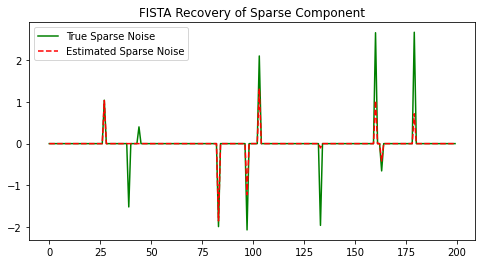

MSE between true and estimated: 0.06881379336118698


In [3]:
plt.figure(figsize=(8,4))
plt.plot(S_true.numpy(), 'g-', label='True Sparse Noise')
plt.plot(S_estimated.detach().numpy(), 'r--', label='Estimated Sparse Noise')
plt.legend()
plt.title("FISTA Recovery of Sparse Component")
plt.show()

print("MSE between true and estimated:", torch.mean((S_estimated - S_true)**2).item())

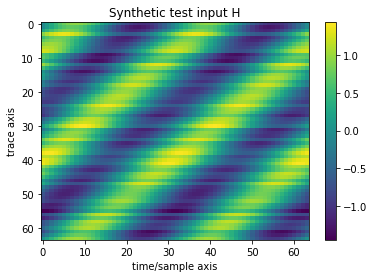

In [4]:
# Create synthetic data (batch=1, channel=1)
nt, nx = 64, 64
x = torch.linspace(0, 4*torch.pi, nx)
t = torch.linspace(0, 4*torch.pi, nt)
X, T = torch.meshgrid(x, t, indexing='ij')

# Smooth signal with directional slope
H = (torch.sin(X + T)) [None,None,:,:]

noise_strength = 0.2   # adjust for stronger/weaker noise

# Create noise that varies only along x (horizontal direction)
horizontal_noise = noise_strength * torch.randn(nx)[..., None]  # shape [nx,1]
horizontal_noise = horizontal_noise.expand(nx, nt)              # broadcast over time

origin_snr = torch.mean(H / horizontal_noise)

# Add to dataset
H += horizontal_noise[None,None,:,:]

plt.imshow(H[0,0].numpy(), cmap='viridis', aspect='auto')
plt.title("Synthetic test input H")
plt.xlabel("time/sample axis")
plt.ylabel("trace axis")
plt.colorbar()
plt.show()

In [5]:
fH = torch.fft.rfftn(torch.transpose(H, -1, -2), dim=(-2, -1), norm='ortho')
M_0 = torch.ones_like(fH, requires_grad=True, dtype=torch.float64)
opt_M = torch.optim.Adam([M_0], lr=.01)
H_filtered, M_estimated = update_M(H, M_0, opt_M, gamma3=.1, num_iters=5000, verbose=False)

snr = torch.mean(H_filtered/(H - H_filtered))

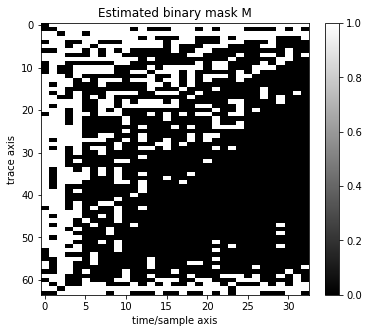

Mask mean value: 0.31534090638160706
Number of active elements: 666


In [6]:
plt.figure(figsize=(6,5))
plt.imshow(M_estimated[0,0].detach().numpy(), cmap='gray', aspect='auto')
plt.title("Estimated binary mask M")
plt.xlabel("time/sample axis")
plt.ylabel("trace axis")
plt.colorbar()
plt.show()

print("Mask mean value:", M_estimated.mean().item())
print("Number of active elements:", torch.sum(M_estimated > 0.5).item())

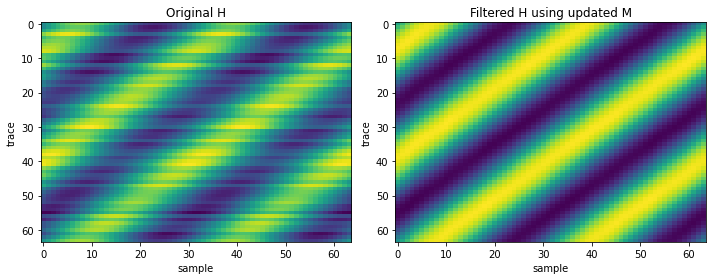

True SNR: -0.20571467280387878
SNR after masking: -7.867258071899414


In [7]:
fig, axs = plt.subplots(1,2, figsize=(10,4))
axs[0].imshow(H[0,0].numpy(), cmap='viridis', aspect='auto')
axs[0].set_title('Original H')
axs[1].imshow(H_filtered[0,0].detach().numpy(), cmap='viridis', aspect='auto')
axs[1].set_title('Filtered H using updated M')
for ax in axs: ax.set_xlabel('sample'); ax.set_ylabel('trace')
plt.tight_layout(); plt.show()

print(f"True SNR: {origin_snr}")
print(f"SNR after masking: {snr}")

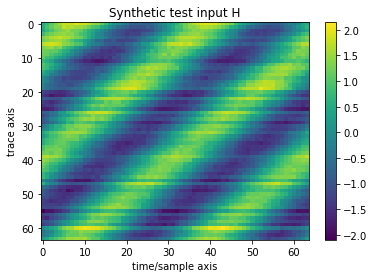

In [8]:
# Synthetic data (batch=1, channel=1, height=64, width=64)
torch.manual_seed(0)

# Create synthetic data (batch=1, channel=1)
nt, nx = 64, 64
x = torch.linspace(0, 4*torch.pi, nx)
t = torch.linspace(0, 4*torch.pi, nt)
X, T = torch.meshgrid(x, t, indexing='ij')

# Smooth signal with directional slope
clean_signal = (torch.sin(X + T)) [None,None,:,:]

random_noise = 0.05 * torch.randn_like(clean_signal)
noise_strength = 0.2   # adjust for stronger/weaker noise

# Create noise that varies only along x (horizontal direction)
horizontal_noise = noise_strength * torch.randn(nx)[..., None]  # shape [nx,1]
horizontal_noise = horizontal_noise.expand(nx, nt)              # broadcast over time

Y = clean_signal + random_noise + horizontal_noise[None,None,:,:]
Y = (Y - Y.mean()) / Y.std()

plt.imshow(Y[0,0].numpy(), cmap='viridis', aspect='auto')
plt.title("Synthetic test input H")
plt.xlabel("time/sample axis")
plt.ylabel("trace axis")
plt.colorbar()
plt.show()

cuda


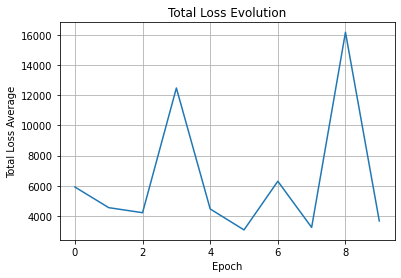

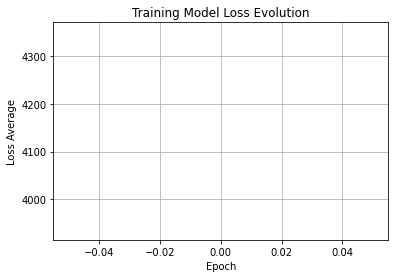

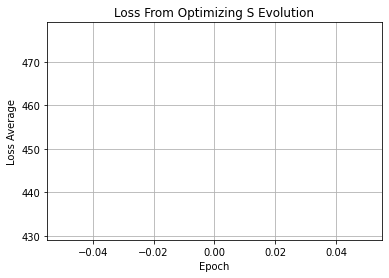

In [9]:
model, S_est, M_est, H_est = train(Y,
                                   lr_model=1e-3,
                                   lr_M=1e-3,
                                   g1=1,
                                   g2=1,
                                   g3=0.05,
                                   n_epoch=10,
                                   it_model=500,
                                   it_S=500,
                                   it_M=10,
                                   tol=1e-6,
                                   step_S=1e-2,
                                   init_w=5e-2)

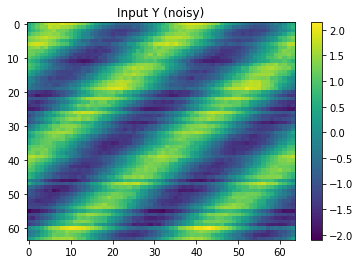

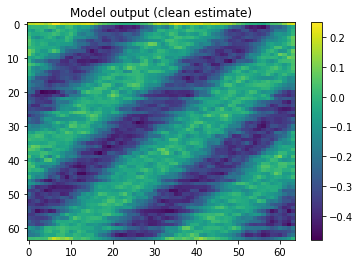

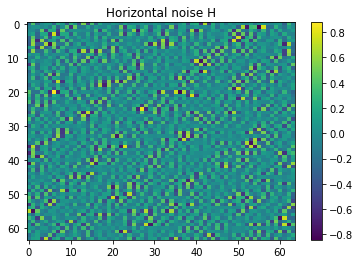

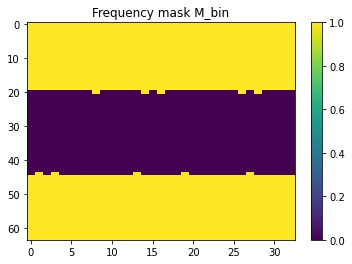

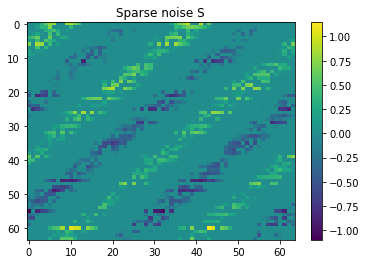

tensor(0.1099, device='cuda:0', grad_fn=<MeanBackward0>) tensor(-0.3803, device='cuda:0', grad_fn=<MeanBackward0>) tensor(-0.3756, device='cuda:0', grad_fn=<MeanBackward0>)


In [10]:
def show_tensor(tensor, title):
    t_np = tensor.squeeze().cpu().detach().numpy()
    plt.imshow(t_np, cmap='viridis', aspect='auto')
    plt.colorbar()
    plt.title(title)
    plt.show()

device = next(model.parameters()).device
Y_device = Y.to(device)
show_tensor(Y_device[0], "Input Y (noisy)")
show_tensor(infer(model, Y_device, M_est, 100)[0,0], "Model output (clean estimate)")
show_tensor(H_est, "Horizontal noise H")
show_tensor(M_est, "Frequency mask M_bin")
show_tensor(S_est, "Sparse noise S")


o1 = torch.mean(model(Y_device))
o2 = torch.mean(model(Y_device))
o3 = torch.mean(model(Y_device))

print(o1,o2,o3)

In [11]:
print(M_est)

tensor([[[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]]]], device='cuda:0')


In [12]:
fY = torch.fft.rfftn(torch.transpose(Y, -1, -2), dim=(-2, -1), norm='ortho')
M_1 = torch.ones_like(fY, requires_grad=True, dtype=torch.float64)
opt_M_1 = torch.optim.Adam([M_1], lr=.5)
Y_filtered, M1_estimated = update_M(Y, M_1, opt_M_1, gamma3=.05, num_iters=5000, verbose=False)

plt.figure(figsize=(6,5))
plt.imshow(M1_estimated[0,0].detach().numpy(), cmap='gray', aspect='auto')
plt.title("Estimated binary mask M")
plt.xlabel("time/sample axis")
plt.ylabel("trace axis")
plt.colorbar()
plt.show()

print("Mask mean value:", M_estimated.mean().item())
print("Number of active elements:", torch.sum(M_estimated > 0.5).item())

fig, axs = plt.subplots(1,3, figsize=(10,4))
axs[0].imshow(Y[0,0].numpy(), cmap='viridis', aspect='auto')
axs[0].set_title('Original H')
axs[1].imshow(Y_filtered[0,0].detach().numpy(), cmap='viridis', aspect='auto')
axs[1].set_title('Filtered H using updated M')
axs[2].imshow(Y[0,0].numpy() - Y_filtered[0,0].detach().numpy(), cmap='viridis', aspect='auto')
axs[2].set_title('Horizontal Noise')
for ax in axs: ax.set_xlabel('sample'); ax.set_ylabel('trace')
plt.tight_layout(); plt.show()

RuntimeError: Trying to backward through the graph a second time (or directly access saved tensors after they have already been freed). Saved intermediate values of the graph are freed when you call .backward() or autograd.grad(). Specify retain_graph=True if you need to backward through the graph a second time or if you need to access saved tensors after calling backward.